In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
train_data=pd.read_csv('train.csv')
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
train_data.shape

(891, 12)

In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


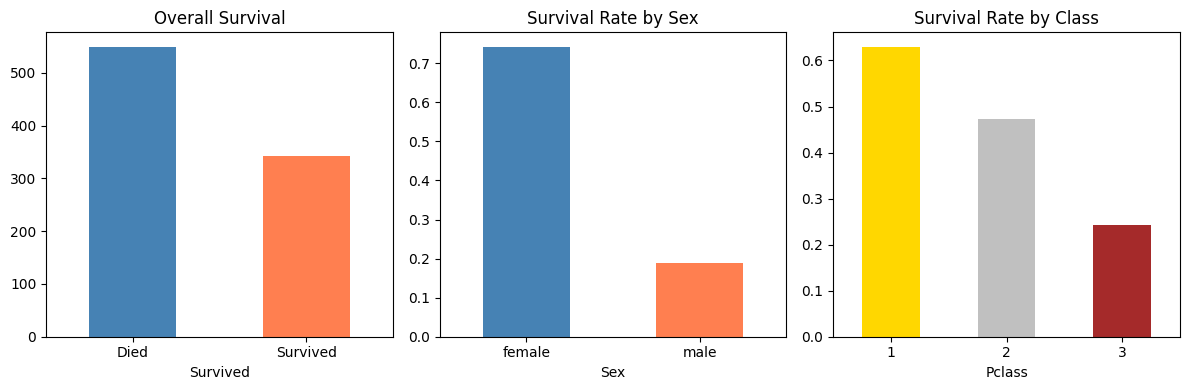

In [ ]:

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
train_data['Survived'].value_counts().plot(kind='bar', color=['steelblue', 'coral'])
plt.title('Overall Survival')
plt.xticks([0, 1], ['Died', 'Survived'], rotation=0)

plt.subplot(1, 3, 2)
train_data.groupby('Sex')['Survived'].mean().plot(kind='bar', color=['steelblue', 'coral'])
plt.title('Survival Rate by Sex')
plt.xticks(rotation=0)

plt.subplot(1, 3, 3)
train_data.groupby('Pclass')['Survived'].mean().plot(kind='bar', color=['gold', 'silver', 'brown'])
plt.title('Survival Rate by Class')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
train_data.isnull().sum().sort_values(ascending=False)

,0
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0


In [ ]:
train_data=train_data.drop(columns=['Cabin','Name','Ticket'])

In [ ]:
train_data['Age']=train_data['Age'].fillna(train_data['Age'].median())

In [ ]:
train_data['Embarked']=train_data['Embarked'].fillna(train_data['Embarked'].mode())

In [ ]:
train_data=pd.get_dummies(train_data, columns=['Embarked'], drop_first=True)
train_data['Sex']=train_data['Sex'].map({'male':0,'female':1})

In [ ]:
train_data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,1,0,3,0,22.0,1,0,7.2500,False,True
1,2,1,1,1,38.0,1,0,71.2833,False,False
2,3,1,3,1,26.0,0,0,7.9250,False,True
3,4,1,1,1,35.0,1,0,53.1000,False,True
4,5,0,3,0,35.0,0,0,8.0500,False,True


In [ ]:
train_data.isnull().sum().sort_values(ascending=False)

,0
PassengerId,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked_Q,0
Embarked_S,0


In [ ]:
X= train_data.drop(columns=['Survived','PassengerId'])
Y= train_data['Survived']

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test= train_test_split(X,Y, test_size=0.2, random_state=42)
lg_model=LogisticRegression(max_iter=1000, random_state=42)
lg_model.fit(X_train, Y_train)
y_pred=lg_model.predict(X_test)

In [ ]:
print(y_pred)

[0 0 0 1 1 1 1 0 1 1 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 1 1 1 0 0 0
 1 1 0 0 0 0 0 1 0 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0 0 1 0 0 0 1 1 1 1 1
 0 0 1 1 1 0 0 1 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1
 0 1 0 1 0 0 0 1 0 0 1 1 0 0 1 1 1 1 0 1 0 0 1 0 1 1 0 0 1 0 1 0 0 0 1 0 0
 1 0 0 0 0 1 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 1 1 0 1 0 0 0 1 1]


Accuracy:  0.8100558659217877

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



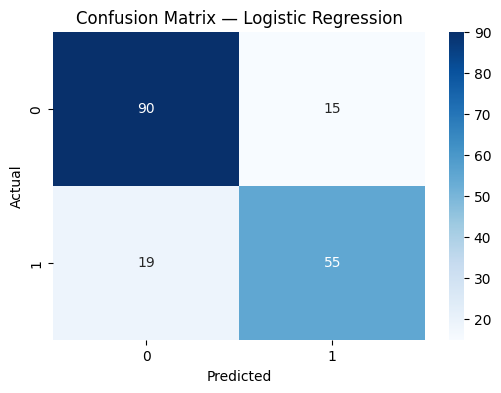

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print('Accuracy: ', accuracy_score(Y_test, y_pred))
print("\nClassification Report:")
print(classification_report(Y_test, y_pred))
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(Y_test, y_pred),
            annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix — Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
train_accuracy = accuracy_score(Y_train, lg_model.predict(X_train))
test_accuracy = accuracy_score(Y_test, y_pred)

print("Train Accuracy:", round(train_accuracy, 4))
print("Test Accuracy :", round(test_accuracy, 4))
print("Gap           :", round(train_accuracy - test_accuracy, 4))

if train_accuracy - test_accuracy < 0.05:
    print("No overfitting — gap is acceptable")
elif train_accuracy - test_accuracy < 0.10:
    print("Mild overfitting — worth monitoring")
else:
    print("Overfitting detected — model is memorising training data")

Train Accuracy: 0.8006
Test Accuracy : 0.8101
Gap           : -0.0095
No overfitting — gap is acceptable


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score

cv_accuracy = cross_val_score(lg_model, X, Y, cv=5, scoring='accuracy')
cv_f1 = cross_val_score(lg_model, X, Y, cv=5, scoring='f1')
cv_roc = cross_val_score(lg_model, X, Y, cv=5, scoring='roc_auc')

print("5-Fold Cross Validation Results:")
print(f"Accuracy : {cv_accuracy.mean():.4f} +/- {cv_accuracy.std():.4f}")
print(f"F1 Score : {cv_f1.mean():.4f} +/- {cv_f1.std():.4f}")
print(f"ROC-AUC  : {cv_roc.mean():.4f} +/- {cv_roc.std():.4f}")

5-Fold Cross Validation Results:
Accuracy : 0.7912 +/- 0.0185
F1 Score : 0.7195 +/- 0.0282
ROC-AUC  : 0.8485 +/- 0.0150


Random Forest Accuracy: 0.7988826815642458

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       105
           1       0.76      0.74      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



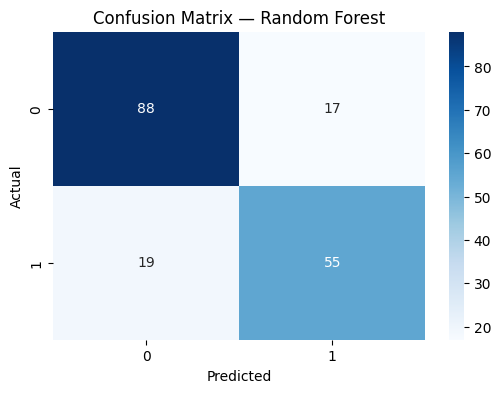

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, Y_train)

rf_pred = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(Y_test, rf_pred))
print("\nClassification Report:")
print(classification_report(Y_test, rf_pred))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(Y_test, rf_pred),
            annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix — Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
rf_cv_accuracy = cross_val_score(rf_model, X, Y, cv=5, scoring='accuracy')
rf_cv_f1 = cross_val_score(rf_model, X, Y, cv=5, scoring='f1')
rf_cv_roc = cross_val_score(rf_model, X, Y, cv=5, scoring='roc_auc')

print("Random Forest 5-Fold CV Results:")
print(f"Accuracy : {rf_cv_accuracy.mean():.4f} +/- {rf_cv_accuracy.std():.4f}")
print(f"F1 Score : {rf_cv_f1.mean():.4f} +/- {rf_cv_f1.std():.4f}")
print(f"ROC-AUC  : {rf_cv_roc.mean():.4f} +/- {rf_cv_roc.std():.4f}")

Random Forest 5-Fold CV Results:
Accuracy : 0.8081 +/- 0.0301
F1 Score : 0.7445 +/- 0.0466
ROC-AUC  : 0.8539 +/- 0.0383


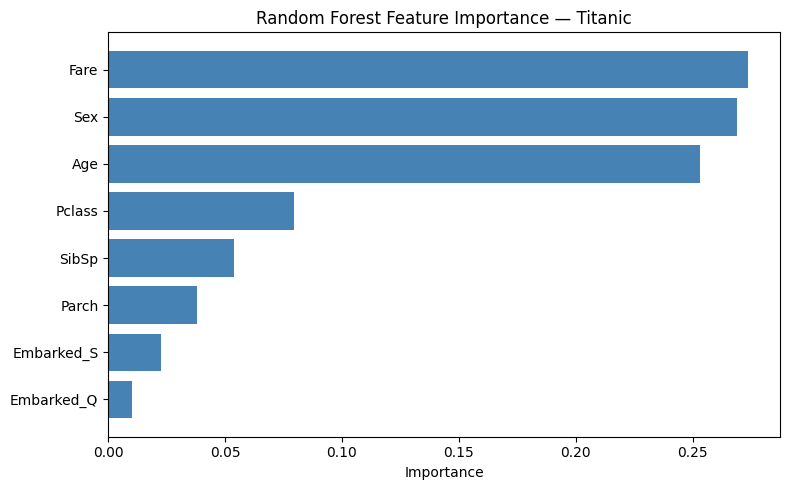

In [ ]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.title('Random Forest Feature Importance — Titanic')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

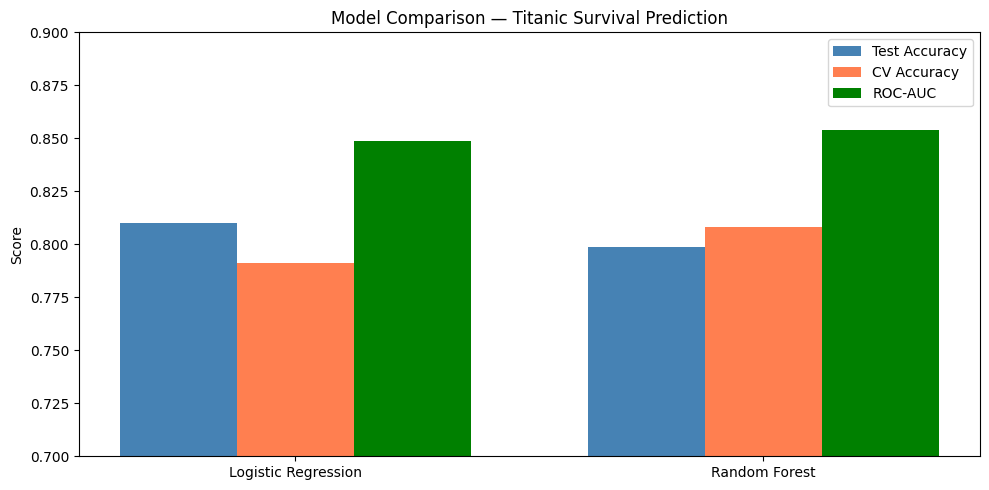

In [ ]:
models = ['Logistic Regression', 'Random Forest']
accuracy = [0.8101, 0.7989]
cv_accuracy = [0.7912, 0.8081]
roc_auc = [0.8485, 0.8539]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, accuracy, width, label='Test Accuracy', color='steelblue')
ax.bar(x, cv_accuracy, width, label='CV Accuracy', color='coral')
ax.bar(x + width, roc_auc, width, label='ROC-AUC', color='green')

ax.set_ylabel('Score')
ax.set_title('Model Comparison — Titanic Survival Prediction')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0.7, 0.9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
test_data=pd.read_csv('test.csv')

In [ ]:
test_data.isnull().sum().sort_values(ascending=False)

,0
Cabin,327
Age,86
Fare,1
Name,0
Pclass,0
PassengerId,0
Sex,0
Parch,0
SibSp,0
Ticket,0


In [ ]:
test_data=test_data.drop(columns=['Cabin','Name','Ticket'])


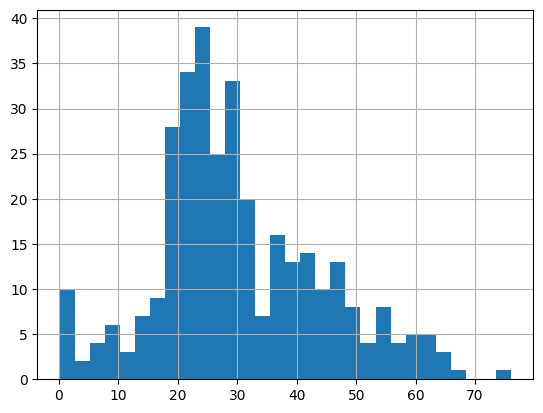

In [ ]:
test_data['Age'].hist(bins=30)
plt.show()

In [ ]:
test_data['Age']=test_data['Age'].fillna(test_data['Age'].median())

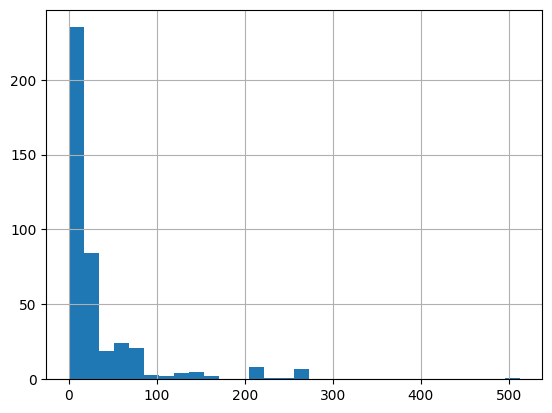

In [ ]:
test_data['Fare'].hist(bins=30)
plt.show()

In [ ]:
test_data['Fare']=test_data['Fare'].fillna(test_data['Fare'].median())

In [ ]:
test_data.isnull().sum().sort_values(ascending=False)

,0
PassengerId,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [ ]:
print(test_data)

     PassengerId  Pclass     Sex   Age  SibSp  Parch      Fare Embarked
0            892       3    male  34.5      0      0    7.8292        Q
1            893       3  female  47.0      1      0    7.0000        S
2            894       2    male  62.0      0      0    9.6875        Q
3            895       3    male  27.0      0      0    8.6625        S
4            896       3  female  22.0      1      1   12.2875        S
..           ...     ...     ...   ...    ...    ...       ...      ...
413         1305       3    male  27.0      0      0    8.0500        S
414         1306       1  female  39.0      0      0  108.9000        C
415         1307       3    male  38.5      0      0    7.2500        S
416         1308       3    male  27.0      0      0    8.0500        S
417         1309       3    male  27.0      1      1   22.3583        C

[418 rows x 8 columns]


In [ ]:
test_data['Sex']=test_data['Sex'].map({'male':0, 'female':1})

In [ ]:
print(test_data)

     PassengerId  Pclass  Sex   Age  SibSp  Parch      Fare Embarked
0            892       3    0  34.5      0      0    7.8292        Q
1            893       3    1  47.0      1      0    7.0000        S
2            894       2    0  62.0      0      0    9.6875        Q
3            895       3    0  27.0      0      0    8.6625        S
4            896       3    1  22.0      1      1   12.2875        S
..           ...     ...  ...   ...    ...    ...       ...      ...
413         1305       3    0  27.0      0      0    8.0500        S
414         1306       1    1  39.0      0      0  108.9000        C
415         1307       3    0  38.5      0      0    7.2500        S
416         1308       3    0  27.0      0      0    8.0500        S
417         1309       3    0  27.0      1      1   22.3583        C

[418 rows x 8 columns]


In [ ]:
test_data=test_data.drop(columns=['PassengerId'])

In [ ]:
test_data=pd.get_dummies(test_data, columns=['Embarked'], drop_first=True)

In [ ]:
print(test_data)

     Pclass  Sex   Age  SibSp  Parch      Fare  Embarked_Q  Embarked_S
0         3    0  34.5      0      0    7.8292        True       False
1         3    1  47.0      1      0    7.0000       False        True
2         2    0  62.0      0      0    9.6875        True       False
3         3    0  27.0      0      0    8.6625       False        True
4         3    1  22.0      1      1   12.2875       False        True
..      ...  ...   ...    ...    ...       ...         ...         ...
413       3    0  27.0      0      0    8.0500       False        True
414       1    1  39.0      0      0  108.9000       False       False
415       3    0  38.5      0      0    7.2500       False        True
416       3    0  27.0      0      0    8.0500       False        True
417       3    0  27.0      1      1   22.3583       False       False

[418 rows x 8 columns]


In [ ]:
test_val=lg_model.predict(test_data)

In [ ]:
print(test_val)

[0 0 0 0 1 0 1 0 1 0 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 0 1 0 0 0 0 0 0 1 0 0 1
 1 0 0 0 0 0 1 1 0 0 0 1 1 0 0 1 1 0 0 0 0 0 1 0 0 0 1 1 1 1 0 1 1 1 0 1 1
 1 1 0 1 0 1 0 0 0 0 0 0 1 1 1 0 1 0 1 0 1 0 1 0 1 0 1 0 0 0 1 0 0 0 0 0 0
 1 1 1 1 0 0 1 1 1 1 0 1 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0
 0 0 1 0 0 1 0 0 1 1 0 1 1 0 1 0 0 1 0 0 1 1 0 0 0 0 0 1 1 0 1 1 0 0 1 0 1
 0 1 0 0 0 0 0 0 0 0 0 1 1 0 1 1 0 0 1 0 1 1 0 1 0 0 0 0 1 0 0 1 0 1 0 1 0
 1 0 1 1 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 1 0 0 0 0 1 0 1 1 1 0 1 0 0 0 0 0 1
 0 0 0 1 1 0 0 0 0 1 0 0 0 1 1 0 1 0 0 0 0 1 0 1 1 1 0 0 0 0 0 0 1 0 0 0 0
 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0
 1 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 0 1 0 0 1 1 0
 0 1 0 0 1 1 1 0 0 0 0 0 1 1 0 1 0 0 0 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 0 0 0
 0 1 1 1 1 1 0 1 0 0 0]


In [ ]:
original_test=pd.read_csv('test.csv')

In [ ]:
Submission= pd.DataFrame({'PassengerId':original_test['PassengerId'],
                          'Survived':test_val})
print(Submission)

     PassengerId  Survived
0            892         0
1            893         0
2            894         0
3            895         0
4            896         1
..           ...       ...
413         1305         0
414         1306         1
415         1307         0
416         1308         0
417         1309         0

[418 rows x 2 columns]


In [ ]:
Submission.to_csv('Submission.csv',index=False)

In [ ]:
# Make predictions on cleaned test data
test_predictions = rf_model.predict(test.drop(columns=['PassengerId']))

# Create submission using PassengerId from original test
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': test_predictions
})

print(submission.head())
print("Shape:", submission.shape)

submission.to_csv('submission.csv', index=False)
print("Saved!")